# All Graph Classes Visual Comparison

This notebook builds every public graph family in `proximitygraphs` on the same deterministic point set, including the bio-inspired `PhysarumGraph` and `FungalGraph`. The goal is to make the differences visible: sparse trees, empty-region graphs, triangulations, radius-threshold graphs, dense baselines, and adaptive biological heuristics.

Artifacts are written to `examples/output/all_graph_classes_notebook/`.

## Setup

The path setup lets the notebook run from the repository root or from inside `examples/`. The example module does the construction and plotting work so the notebook stays focused on interpretation.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "examples").exists():
            return path
    raise RuntimeError("Run this notebook from the repository or examples folder.")


REPO_ROOT = find_repo_root()
EXAMPLES_DIR = REPO_ROOT / "examples"
OUTPUT_DIR = EXAMPLES_DIR / "output" / "all_graph_classes_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(EXAMPLES_DIR))

import all_graph_classes_gallery as gallery

## Build Every Graph on the Same Points

Using one point set keeps the comparison fair. Edge counts and densities become directly comparable because the vertex set never changes.

In [2]:
points, graphs = gallery.build_all_graphs()
metrics = gallery.graph_metrics(graphs)

print(f"points: {points.n}")
print(f"graphs: {len(graphs)}")
list(graphs)

points: 12
graphs: 18


['Complete',
 'Delaunay',
 'Convex hull',
 'MST',
 'Unit disk',
 'Gabriel',
 'RNG',
 'Beta skeleton',
 'Nearest neighbor',
 'Sphere influence',
 'Sigma graph',
 'Elliptic Gabriel',
 'Stepping stone',
 'Alpha shape',
 'Alpha hull',
 'Gamma graph',
 'Physarum',
 'Fungal']

## Visual Gallery

Each panel shows one graph family. The subtitle reports the number of edges and connected components. This is often the fastest way to see whether a graph is acting like a sparse backbone, a dense neighborhood model, or a boundary extractor.

examples\output\all_graph_classes_notebook\all_graph_classes.png


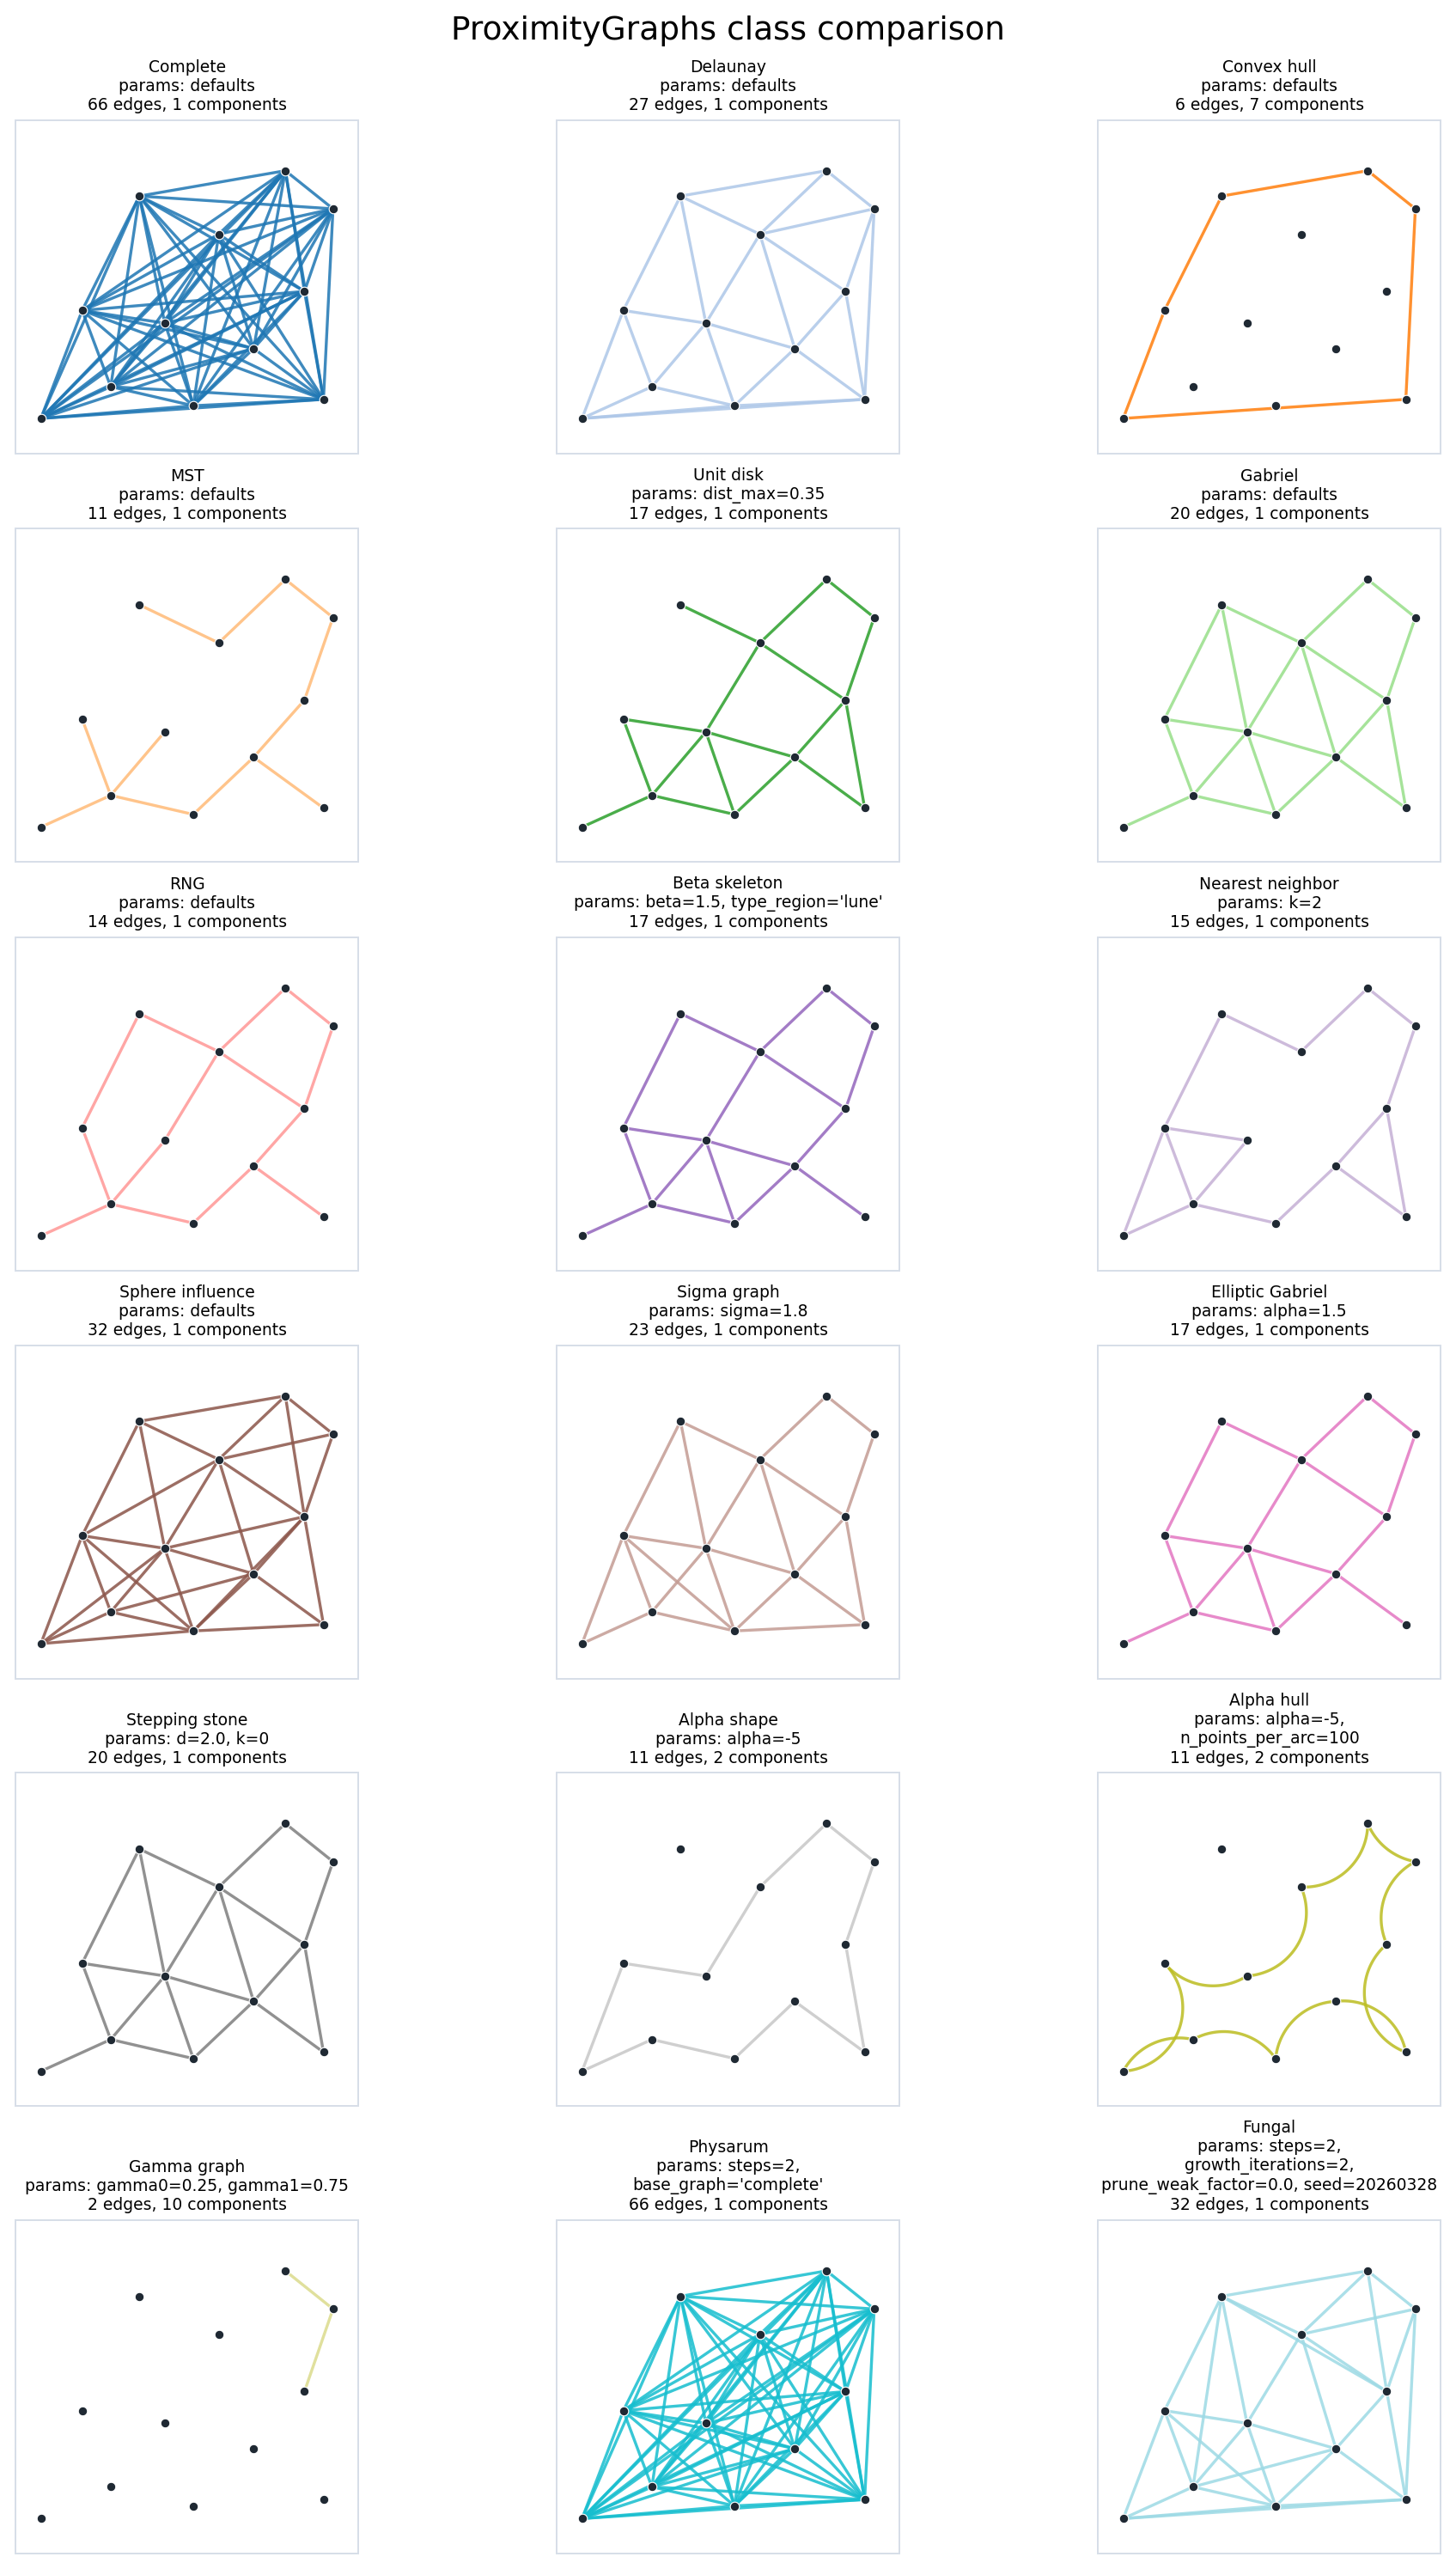

In [3]:
gallery_path = gallery.save_gallery(graphs, OUTPUT_DIR)
print(gallery_path.relative_to(REPO_ROOT))
display(Image(filename=str(gallery_path)))

## Metrics Table

`density` normalizes edge count by the complete graph size. `total_length` and `mean_length` expose geometric cost: two graphs can have similar edge counts but very different length profiles.

In [4]:
csv_path, markdown_path = gallery.write_metrics(metrics, OUTPUT_DIR)
print(csv_path.relative_to(REPO_ROOT))
metrics.sort_values("edges").reset_index(drop=True)

examples\output\all_graph_classes_notebook\metrics.csv


,graph,vertices,edges,components,density,total_length,mean_length
0,Gamma graph,12,2,10,0.0303,0.4672,0.2336
1,Convex hull,12,6,7,0.0909,2.9183,0.4864
2,Alpha shape,12,11,2,0.1667,3.0994,0.2818
3,MST,12,11,1,0.1667,2.8364,0.2579
4,Alpha hull,12,11,2,0.1667,3.0994,0.2818
5,RNG,12,14,1,0.2121,3.8910,0.2779
6,Nearest neighbor,12,15,1,0.2273,4.2112,0.2807
7,Unit disk,12,17,1,0.2576,4.6631,0.2743
8,Elliptic Gabriel,12,17,1,0.2576,4.7204,0.2777
9,Beta skeleton,12,17,1,0.2576,4.7204,0.2777


## Edge Count Comparison

The bar chart sorts graph families by edge count. Complete and Physarum-with-complete-base sit at the dense end here, while the gamma setting used in this example is deliberately sparse.

examples\output\all_graph_classes_notebook\edge_counts.png


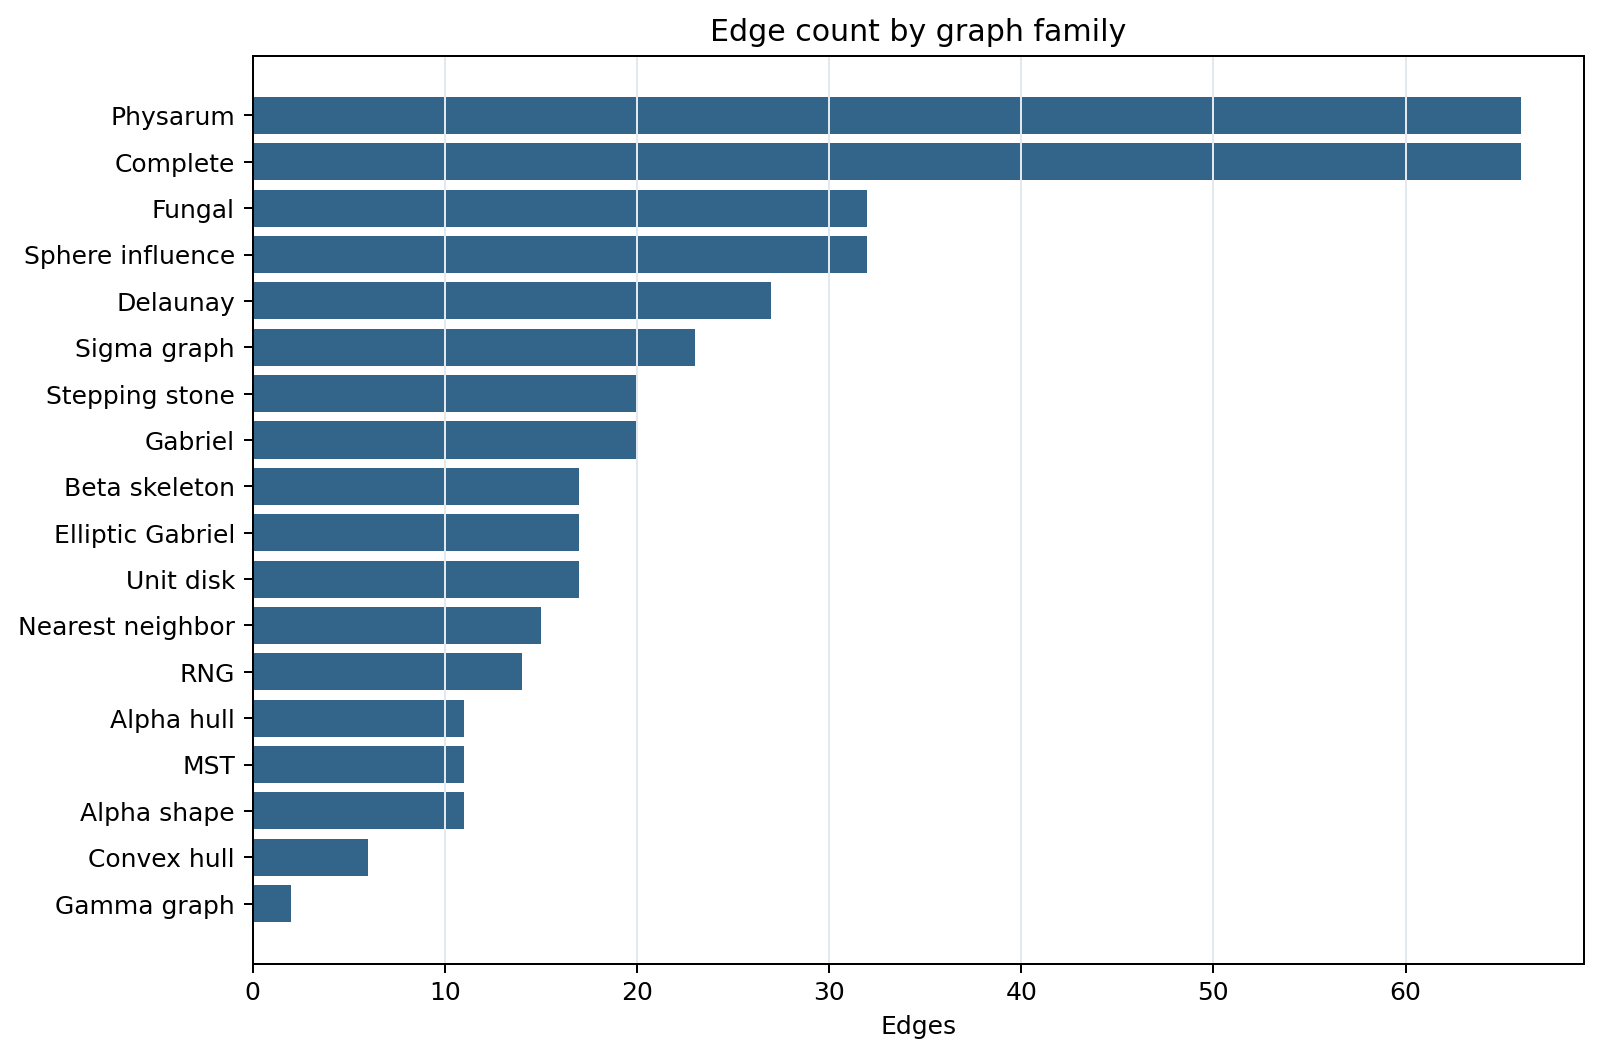

In [5]:
edge_count_path = gallery.save_edge_count_plot(metrics, OUTPUT_DIR)
print(edge_count_path.relative_to(REPO_ROOT))
display(Image(filename=str(edge_count_path)))

## Reading the Comparison

- `MST`, `RNG`, and related empty-region graphs form sparse backbones.
- `Delaunay` is a useful supergraph for many planar proximity structures.
- `Unit disk`, `SIG`, and `Sigma_Graph` respond strongly to radius/local-density choices.
- `Alpha_Shape`, `Alpha_Hull`, and `Convex hull` emphasize boundary structure.
- `PhysarumGraph` and `FungalGraph` are bio-inspired models; their behavior depends on base graph and growth/pruning parameters.

The saved PNGs and metrics table make this notebook useful as a quick visual reference when choosing a graph family.